# 第11课 · 三把尺子量一个向量——L1 / L2 / ∞ 范数（norm）与归一化的几何

**目标**：会算 L1/L2/∞ 范数与距离，并把向量归一化成单位长度。

> 写 `normalize` 前必看：「不能用 sum/max 归一」那一追问。Lasso 正则细节可留到训练课。

**为什么对 Aurora 重要**：MSE ≈ 误差 L2 平方；MFCC 送模型前常 L2 归一，让不同帧能量同尺度。

← **上一课**　[L10 · 点积与投影](L10_dot_product.ipynb)

> 上节课学习了 **点积与投影**：a·b = |a||b|cosθ，为什么相似度 = 点积 ÷ 积范数。  
> 本课将探讨 **向量范数**。

## 本课剧情：量"距离"有多种尺子

你在地图上量两点之间的距离，有几种方法：
- **直线距离**（鸟飞过去的路）：用勾股定理，这就是 **L2 范数**
- **街区距离**（出租车沿街道走的路）：沿x轴走+沿y轴走，这就是 **L1 范数**
- **最远的那步**（棋盘上国王走法）：只看最长的那个分量，这就是 **L∞ 范数**

三把"尺子"，三种不同的"长度"定义。哪种合适，取决于任务：
- **L2**：几何距离，MFCC 归一化（normalization），神经网络权重衰减（L2 regularization）
- **L1**：稀疏性，Lasso 回归，对异常值更鲁棒
- **L∞**：最坏情况下的误差界

本课唯一的练习：实现 `normalize(v)`——把任意向量压缩到单位 L2 球上（长度变为 1）。

## 1. 三种范数，三把尺子

给向量 `v = [v₁, v₂, ..., vₙ]`，三种"长度"定义：

| 范数 | 公式 | 几何含义 | Aurora 用途 |
|---|---|---|---|
| L2（欧式）| `√(Σ vᵢ²)` | 直线距离（勾股定理推广）| MFCC 归一化、余弦相似度分母 |
| L1（曼哈顿）| `Σ |vᵢ|` | 街区距离 | Lasso 正则化，对异常值鲁棒 |
| L∞（切比雪夫）| `max(|vᵢ|)` | 最大分量 | 最坏误差界 |

**手算练习**（v = [3, 4]，先在纸上算，再运行代码对答案）：

| 范数 | 手算 |
|---|---|
| L2 | ✏️ √(9+16) = ? |
| L1 | ✏️ 3+4 = ? |
| L∞ | ✏️ max(3,4) = ? |

### 补充：「切比雪夫」是谁？L∞ 到底在量什么？

表格里 L∞ 后面括号写着"切比雪夫"——这是数学家 **切比雪夫（Pafnuty Chebyshev）** 的名字，他研究"最坏情况下的误差有多大"这类问题，而 L∞ 范数（只看最大分量）正好就是衡量"最坏那一项偏差有多大"的工具，所以后人用他的名字命名了这种度量方式。它还有个更接地气的外号——**棋盘距离 / 切比雪夫距离**，因为国际象棋里的王每走一步，横、竖、斜方向都算"一步"，走到目标格子所需的步数，就等于横向格数和纵向格数中**较大的那一个**，这正是 L∞ 的定义。

如果棋盘的比喻还是有点陌生，换一个日常场景：质检员在检查一件衣服，量出胸围、袖长、腰围三处和标准尺寸的偏差 `[+2cm, -1cm, +5cm]`。质检员通常不关心"三处偏差加起来有多少"（那是 L1 的思路），只关心**最严重超标的那一处**——`|+5cm|` 最大，这件衣服就按"偏差 5cm"判定是否合格。这就是 L∞：**不看总量，只看最坏的那一个分量**，因此它天然适合"最坏情况误差界"这类场景。



### 记号答疑：`‖v‖` 和高中学过的 `|x|` 有什么关系？

高中学过 `|x|`（绝对值），比如 `|-5|=5`——它是给**一个数字**量"离 0 有多远"的尺子，规则很简单：去掉负号。

但向量 `v=[3,4]` 不是一个数字，而是好几个数字捆在一起，"离原点有多远"不能只是去掉负号，需要勾股定理或者别的公式把多个分量合成一个长度。为了提醒读者"这不是普通绝对值，而是给向量（以后还会给矩阵）专门定义的、更复杂的长度"，数学家干脆发明了一个新符号——两道竖线 `‖ ‖`，专门用在向量和矩阵上。

简单总结：
- `|x|`：给**一个数**用的，公式固定（去掉负号）。
- `‖v‖`：给**一个向量**用的，公式不止一种（勾股定理、绝对值求和……），所以要在右下角写个角标，比如 `‖v‖₂`、`‖v‖₁`，指明具体用哪一种。下面马上就会看到这些角标分别代表什么。



## 符号入口：先看范数，再看归一化

L2 范数写作 `‖v‖₂`，L1 写作 `‖v‖₁`。给向量 `v = [3, 4]`：`‖v‖₂ = sqrt(9+16) = 5`，`‖v‖₁ = 3+4 = 7`。两个范数都量「长度」，但 L2 对大分量惩罚更重，L1 对各分量一视同仁。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
v = np.array([3.0, 4.0])
print('手算:', np.sqrt(np.sum(v**2)))   # 5.0
print('numpy:', np.linalg.norm(v))      # 5.0
print('L1 范数(绝对值之和):', np.sum(np.abs(v)))

手算: 5.0
numpy: 5.0
L1 范数(绝对值之和): 7.0


## 动手观察：同一向量，两种长度

运行下方代码，注意 L1 和 L2 给出的数值不同，但归一化后向量的 L2 范数恰好等于 1。改动某个分量的大小，观察哪个范数变化更剧烈。

In [3]:
import numpy as np

# L1 vs L2 vs L∞ 范数的数值对比
vecs = [np.array([3., 4.]), np.array([1., 0., 0., 10.]), np.array([-2., 2., -2.])]
for v in vecs:
    l1 = np.sum(np.abs(v))
    l2 = np.sqrt(np.sum(v**2))
    linf = np.max(np.abs(v))
    print(f'v={v}  L1={l1:.2f}  L2={l2:.2f}  L∞={linf:.2f}')
print('观察：L2 比 L1 小（三角不等式），L∞ 最小（只看最大分量）。')


v=[3. 4.]  L1=7.00  L2=5.00  L∞=4.00
v=[ 1.  0.  0. 10.]  L1=11.00  L2=10.05  L∞=10.00
v=[-2.  2. -2.]  L1=6.00  L2=3.46  L∞=2.00
观察：L2 比 L1 小（三角不等式），L∞ 最小（只看最大分量）。


### 追问：为什么 L∞ ≤ L2 ≤ L1 总是成立？

先澄清一个常见的误解：**这三个范数不是在比赛"谁算出的距离更短、更真实"**，它们是三把完全不同的尺子，各自服务不同的任务，没有谁对谁错。比如 `v=[1, 100]`：L∞ 说"距离"是 100，并不是在说"沿对角线走只要 100"，而是在说"如果你只关心这个向量里最大的那个分量，它是 100"——这本来就是 L∞ 的定义，跟"最短路径"无关。选哪把尺子，取决于你关心的是"最坏的一项"（L∞）、"总的偏离"（L1）还是"几何直线距离"（L2）。

不过，对**同一个**向量，三把尺子量出来的数值确实总满足 `L∞ ≤ L2 ≤ L1`，这不是巧合，可以直接从公式推出来（设 `v=[v₁,...,vₙ]`，用 `M = max(|v₁|,...,|vₙ|)` 表示最大分量的绝对值，也就是 L∞）：

**第一步，L∞ ≤ L2：**
```
L2² = v₁² + v₂² + ... + vₙ²  ≥ M²   （因为 M 是其中某一个 |vᵢ|，其余项都 ≥ 0，只会让和更大)
所以 L2 = √(L2²) ≥ √(M²) = M = L∞
```

**第二步，L2 ≤ L1：**
```
L1² = (|v₁| + |v₂| + ... + |vₙ|)²
    = v₁² + v₂² + ... + vₙ²  +  2·(所有 |vᵢ|·|vⱼ| 交叉项之和，i≠j)
    ≥ v₁² + v₂² + ... + vₙ²   （交叉项都 ≥ 0，去掉它们只会让式子变小）
    = L2²
所以 L1 = √(L1²) ≥ √(L2²) = L2
```

两步拼起来：`L∞ ≤ L2 ≤ L1`，对任意向量、任意维度都成立，不需要一个个例子去验证。下面用几何图形直观感受一下——三种"单位球"（`‖v‖=1` 的所有点连成的形状）互相嵌套，谁能"用更小的尺子量到 1"，谁的球就更大。



正方形（L∞）包住圆（L2），圆又包住菱形（L1）。
球越大，说明达到"长度=1"越"容易"（需要更小的坐标值），对应的范数数值就越小——
这正是 L∞ ≤ L2 ≤ L1 在几何图形上的样子。


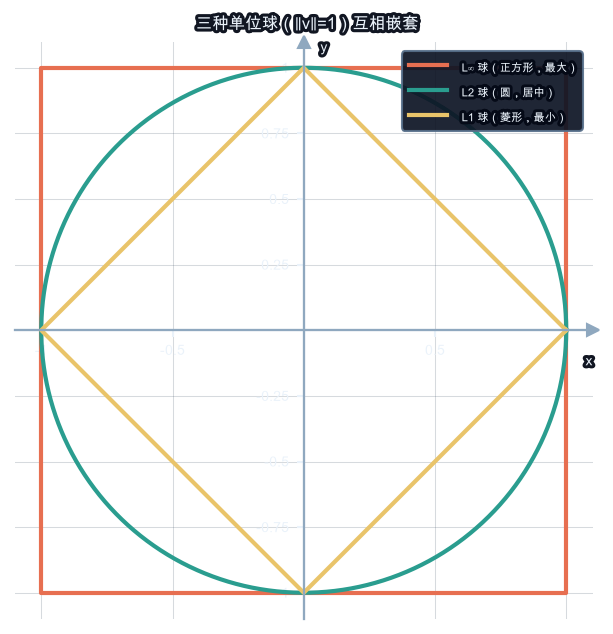

In [4]:
from aurora.laviz import style
import matplotlib.pyplot as plt
import numpy as np

style()
fig, ax = plt.subplots(figsize=(5, 5))

# L∞ 单位球：正方形，四个角在 (±1, ±1)
square = np.array([[1, 1], [-1, 1], [-1, -1], [1, -1], [1, 1]])
ax.plot(square[:, 0], square[:, 1], color='#E76F51', lw=2, label='L∞ 球（正方形，最大）')

# L2 单位球：单位圆
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='#2A9D8F', lw=2, label='L2 球（圆，居中）')

# L1 单位球：菱形，四个角在 (±1,0)、(0,±1)
diamond = np.array([[1, 0], [0, 1], [-1, 0], [0, -1], [1, 0]])
ax.plot(diamond[:, 0], diamond[:, 1], color='#E9C46A', lw=2, label='L1 球（菱形，最小）')

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal')
ax.set_title('三种单位球（‖v‖=1）互相嵌套')
ax.legend(loc='upper right', fontsize=9)
plt.show()

print('正方形（L∞）包住圆（L2），圆又包住菱形（L1）。')
print('球越大，说明达到"长度=1"越"容易"（需要更小的坐标值），对应的范数数值就越小——')
print('这正是 L∞ ≤ L2 ≤ L1 在几何图形上的样子。')


## 代码实验：遍历几个向量，对比 L1 / L2 范数

L2 范数对分量中的极端值更敏感——一个很大的分量会显著拉高 L2、但对 L1 的影响只是线性的。下面的循环展示这个差距如何随向量的「尖锐程度」变化。

In [5]:
import numpy as np

# 对离群值的敏感度：L1 比 L2 更鲁棒
base = np.ones(10)
for outlier in [0, 1, 5, 10, 50]:
    v = base.copy(); v[0] = outlier
    print(f'v[0]={outlier:>3d}  L1={np.linalg.norm(v,1):.1f}  '
          f'L2={np.linalg.norm(v,2):.2f}  L∞={np.linalg.norm(v,np.inf):.0f}')
print('→ L2 被离群值放大（平方），L1 线性增长；当离群值 ≥ 其余分量时，L∞ 直接等于离群值（v[0]=0、1 时 L∞ 仍是其余分量的 1）。')


v[0]=  0  L1=9.0  L2=3.00  L∞=1
v[0]=  1  L1=10.0  L2=3.16  L∞=1
v[0]=  5  L1=14.0  L2=5.83  L∞=5
v[0]= 10  L1=19.0  L2=10.44  L∞=10
v[0]= 50  L1=59.0  L2=50.09  L∞=50
→ L2 被离群值放大（平方），L1 线性增长；当离群值 ≥ 其余分量时，L∞ 直接等于离群值（v[0]=0、1 时 L∞ 仍是其余分量的 1）。


## 2. 两个向量的距离 = 差向量的长度

**先想清楚这个逻辑关系**：为什么两点的距离要"先算差向量，再取长度"，而不是直接对坐标做点别的运算？

想象你站在地图上的点 `A=(1,2)`，朋友站在点 `B=(4,6)`。要知道你俩隔多远，你会怎么算？直觉上会说："横着差了 `4-1=3`，竖着差了 `6-2=4`，再用勾股定理 `√(3²+4²)=5`"。

把这个直觉翻译成向量语言，正好就是两步：
1. **先算"从 A 走到 B 要往右移多少、往上移多少"**——这就是向量减法 `b - a = [4-1, 6-2] = [3, 4]`。这个结果本身就是一个向量：它是"连接 A、B 的那根位移箭头"，方向从 A 指向 B。
2. **再量这根箭头有多长**——对这根差向量取范数，`‖b - a‖₂ = √(3²+4²) = 5`。

所以"两点的距离"根本不是一个凭空发明的新公式，而是"先求出位移向量，再用已经学过的范数量它的长度"——差向量 `b-a` 的坐标，恰好就是逐个分量相减的结果。这就是为什么 `dist(a, b) = ‖a - b‖`：范数把"向量有多长"这件事，直接搬来量"两点差多远"。下面用代码验证这个 2D 例子，并画图看看 a、b、b-a 三个向量。

In [6]:
a = np.array([1.0, 2.0]); b = np.array([4.0, 6.0])
print('距离 =', np.linalg.norm(a - b))  # 5.0

距离 = 5.0


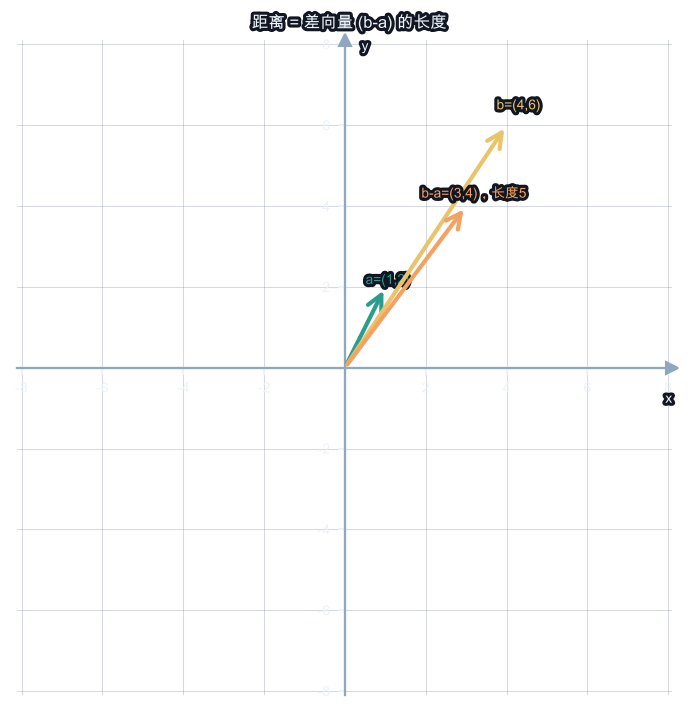

In [7]:
from aurora.laviz import style, arrows2d
style()
arrows2d([a, b, b - a], ['a=(1,2)', 'b=(4,6)', 'b-a=(3,4)，长度5'],
         title='距离 = 差向量 (b-a) 的长度')


## 3. ✏️ 你的任务：实现 `normalize`（缩放到长度为 1）

**推理路线**：
1. 输入 `v` 是形状 `(n,)` 的一维数组，目标是让输出向量的 L2 范数等于 1。
2. 先算 `length = np.linalg.norm(v)`——向量的「总长度」。
3. 用 `v / length` 把每个分量同比缩小：各分量比值（方向）不变，长度从 `length` 变成 `length/length = 1`。关键点：不能用 `v / np.sum(v)` 或 `v / np.max(v)`，那些不能保证 `‖result‖₂ = 1`。
4. **零向量边界**：如果 `length == 0`，`v / length` 产生 NaN。约定：零向量应返回全零向量。用 `if length == 0: return v` 提前拦截——非零向量走精确的 `v / length`（范数恰好为 1），零向量原样返回全零，既不除零也不引入误差。

**为什么是这样约定，而不是直接抛异常？** 想象 Aurora 的 MFCC 特征提取：如果某一帧音频正好是**完全静音**（比如一段录音开头、或者说话人停顿的那几帧），这一帧算出来的特征向量就可能恰好是全零 `[0,0,...,0]`。零向量没有方向——它不指向任何地方，所以"把零向量单位化"这件事本身在数学上就没有定义。这时有两种做法：
- **抛出异常**，中断整个流水线——但静音是完全正常的输入（对话中间的停顿很常见），不该让程序因为这一帧就崩溃；
- **返回全零向量**——长度仍然是 0，没有编造一个不存在的方向；后续代码（比如计算余弦相似度）如果收到全零向量，会自然地得到相似度 0（"跟谁都不像"），而不是让 `0/0` 产生 `NaN` 并一路污染后面所有依赖它的计算。

两种做法都"数学上说得通"，但工程上第二种更安全：**约定不让 NaN 出现，把"没有方向、不确定"编码成"零"，而不是编码成"程序崩溃"**——这也是为什么很多数值库（包括 Aurora 自己的代码）在遇到除零风险时，普遍选择返回一个安全的默认值而不是直接抛异常。

**参考输入输出**：`v=[3,4]` → 范数 5，归一化后 `[0.6, 0.8]`，验证 `0.6²+0.8²=1.0`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 追问：为什么不能用 `v / np.sum(v)` 或 `v / np.max(v)`？

直觉上，除以"总和"或"除以最大值"好像也能把向量"压小"。但我们的目标很具体：让结果的 **L2 范数**（勾股定理算出的长度）恰好变成 1，而不是随便变小。下面直接跑三种除法，看看它们各自除完之后的 L2 范数到底是多少：

In [8]:
v_demo = np.array([3.0, 4.0])
print('原始 v:', v_demo)
for name, divisor in [('sum(v)', np.sum(v_demo)), ('max(v)', np.max(v_demo)),
                       ('‖v‖₂ (正确)', np.linalg.norm(v_demo))]:
    result = v_demo / divisor
    print(f'v / {name:11s} = {divisor:.1f}  ->  结果={result}  结果的 L2 范数={np.linalg.norm(result):.4f}')


原始 v: [3. 4.]
v / sum(v)      = 7.0  ->  结果=[0.42857143 0.57142857]  结果的 L2 范数=0.7143
v / max(v)      = 4.0  ->  结果=[0.75 1.  ]  结果的 L2 范数=1.2500
v / ‖v‖₂ (正确)   = 5.0  ->  结果=[0.6 0.8]  结果的 L2 范数=1.0000


运行结果只有除以 `‖v‖₂` 那一行，结果的 L2 范数恰好是 `1.0000`；除以 `sum` 或 `max` 得到的向量，长度既不是 1，也没有一个统一的规律。这不是巧合——只要除数不是 `‖v‖₂`，结果的长度就不可能被保证等于 1。

### 小证明：为什么 `v / c` 的长度就是 `‖v‖₂ / c`（范数的"齐次性"）

上面是数值验证，下面给出一般性的推导，证明"除以自己的 L2 范数，结果的范数必然是 1"对**任意**向量都成立，不需要每次都代入具体数字验证。设 `v = [v₁, v₂, ..., vₙ]`，`c > 0` 是任意正数：

```
‖v/c‖₂ = √( (v₁/c)² + (v₂/c)² + ... + (vₙ/c)² )
       = √( (1/c²) · (v₁² + v₂² + ... + vₙ²) )
       = √(1/c²) · √(v₁² + v₂² + ... + vₙ²)          ← 根号可以拆成两个根号相乘
       = (1/c) · ‖v‖₂                                 ← 因为 c>0 时 √(1/c²) = 1/c
```

这个性质叫"齐次性"：把向量整体缩放 `1/c` 倍，它的范数也跟着缩放 `1/c` 倍。现在把这个通用结论里的 `c` 代入成 `‖v‖₂` 本身：

```
‖ v / ‖v‖₂ ‖₂  =  ‖v‖₂ / ‖v‖₂  =  1
```

这就严格证明了：只要除以向量自己的 L2 范数，结果的 L2 范数一定精确等于 1——这是从公式推出来的必然结果，而不是"恰好在 [3,4] 这个例子上凑巧成立"。

### 写 `normalize` 前明确三件事

- 输入：`v`，形状 `(n,)` 的浮点向量
- 关键步骤：计算 `length = np.linalg.norm(v)`，再做 `v / length`
- 返回：与 `v` 形状相同、L2 范数等于 1 的单位向量

In [9]:
def normalize(v):
    # ✏️ TODO: 返回单位长度向量
    # 提示：length = np.linalg.norm(v)；若 length == 0 返回 v（全零），否则返回 v / length
    raise NotImplementedError("TODO: divide v by its L2 norm")

In [10]:
try:
    u = normalize(np.array([3.0, 4.0]))
    print("归一化后:", u, "| 长度:", round(float(np.linalg.norm(u)), 6))
    assert abs(np.linalg.norm(u) - 1.0) < 1e-9, "归一化后长度应为 1"
    assert np.allclose(u, [0.6, 0.8], atol=1e-9), "方向错误：v=[3,4] 应归一化为 [0.6, 0.8]"

    # 负分量：方向不受符号影响
    u_neg = normalize(np.array([-6.0, 8.0]))
    assert abs(np.linalg.norm(u_neg) - 1.0) < 1e-9, "负分量向量归一化后长度仍应为 1"
    assert np.allclose(u_neg, [-0.6, 0.8], atol=1e-9), "方向错误：v=[-6,8] 应归一化为 [-0.6, 0.8]"

    # 零向量：eps 保护，不产生 nan，不抛出异常
    z = normalize(np.array([0.0, 0.0]))
    assert not np.any(np.isnan(z)), "零向量归一化不应产生 nan"
    print("\n✅ 通过：[3,4] 方向、负分量方向、零向量三种边界全过。")
except (NotImplementedError, TypeError) as e:
    print(f"⚠️  尚未实现，请完成 normalize()：{e}")


⚠️  尚未实现，请完成 normalize()：TODO: divide v by its L2 norm


**🔗 Aurora 连接**：`normalize(v)` 在 Aurora 的 MFCC 流水线中对每帧特征调用，归一化后余弦相似度（cosine similarity）等价于 `np.dot(a, b)`。说话人识别（speaker recognition）比对的是 d-vector 方向而非幅度——两段录音音量差异很大，归一化后方向相近则判定为同一说话人。

### 验证：为什么"归一化后点积 = 余弦相似度"？

回忆上一课的公式：`cos(θ) = (a·b) / (‖a‖·‖b‖)`。如果 `a`、`b` 都先归一化成单位向量 `â = a/‖a‖`、`b̂ = b/‖b‖`（也就是 `‖â‖=‖b̂‖=1`），那么：

```
â · b̂ = (a/‖a‖) · (b/‖b‖) = (a·b) / (‖a‖·‖b‖) = cos(θ)
```

也就是说，`â · b̂` 和原始的 `cos(θ)` 公式其实是**同一个表达式**，只是把除法提前做在了向量上而已——不是巧合，是代数上的恒等式。下面用两组向量分别验证：第一组是"方向相同、幅度不同"的 `a=[3,4]`、`b=[6,8]`（Aurora 里对应两段音量不同但音色相同的录音）；第二组换成方向不同的向量，确认这个等式不是只在"方向相同"时才成立。

In [11]:
# 第一组：方向相同、幅度不同（b 恰好是 a 放大 2 倍）
a_raw = np.array([3.0, 4.0])
b_raw = np.array([6.0, 8.0])
cos_raw = np.dot(a_raw, b_raw) / (np.linalg.norm(a_raw) * np.linalg.norm(b_raw))
a_unit = a_raw / np.linalg.norm(a_raw)
b_unit = b_raw / np.linalg.norm(b_raw)
dot_unit = np.dot(a_unit, b_unit)
print('第一组 a=[3,4], b=[6,8]')
print('  原始余弦相似度 cos(θ)      =', cos_raw)
print('  归一化后直接点积 â·b̂       =', dot_unit)
print('  两者相等:', np.isclose(cos_raw, dot_unit))

# 第二组：方向不同，确认这不是"方向相同时才成立"的巧合
a2, b2 = np.array([1.0, 0.0]), np.array([1.0, 1.0])
cos2 = np.dot(a2, b2) / (np.linalg.norm(a2) * np.linalg.norm(b2))
dot2 = np.dot(a2 / np.linalg.norm(a2), b2 / np.linalg.norm(b2))
print('\n第二组 a=[1,0], b=[1,1]')
print('  原始余弦相似度 cos(θ)      =', cos2)
print('  归一化后直接点积 â·b̂       =', dot2)
print('  两者相等:', np.isclose(cos2, dot2))


第一组 a=[3,4], b=[6,8]
  原始余弦相似度 cos(θ)      = 1.0
  归一化后直接点积 â·b̂       = 1.0
  两者相等: True

第二组 a=[1,0], b=[1,1]
  原始余弦相似度 cos(θ)      = 0.7071067811865475
  归一化后直接点积 â·b̂       = 0.7071067811865475
  两者相等: True


## 🎨 图示：L2 范数 = 箭头长度 (3,4)→5

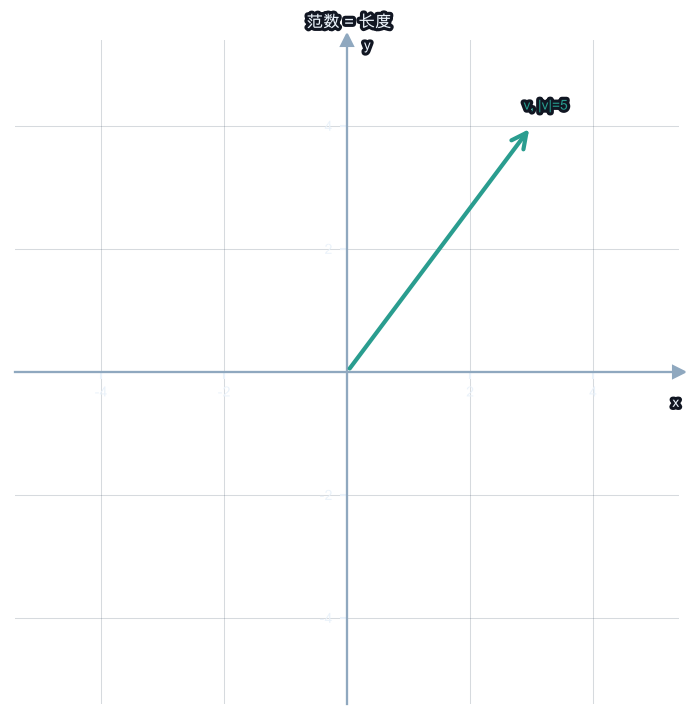

In [12]:
from aurora.laviz import style, arrows2d
style()
arrows2d([[3,4]], ['v, |v|=5'], title='范数 = 长度');

## 揭秘：L1、L2、L∞ 其实是同一个公式的三个特例

到目前为止，L1、L2、L∞ 看起来像是三条互不相关、需要分别背下来的公式。其实它们都是同一个"模具"在通用公式里代入不同的 `p` 得到的：

```
‖v‖ₚ = ( |v₁|^p + |v₂|^p + ... + |vₙ|^p )^(1/p)
```

代入几个具体的 `p`，你会发现熟悉的公式自己冒出来：

- **p=1**：`‖v‖₁ = (|v₁|¹+...+|vₙ|¹)^(1/1) = |v₁|+...+|vₙ|`——正是 L1（绝对值求和）。
- **p=2**：`‖v‖₂ = (|v₁|²+...+|vₙ|²)^(1/2) = √(v₁²+...+vₙ²)`——正是 L2（勾股定理）。
- **p→∞**：当 `p` 变得非常大，公式里"最大的那个 `|vᵢ|^p`"会把其余项远远甩开（比如 `5¹⁰⁰` 比 `3¹⁰⁰` 大出好几个数量级，其余项加起来都可以忽略），所以整个和几乎完全由最大分量决定，开 `p` 次方后趋近于 `max(|vᵢ|)`——正是 L∞。

这也是为什么 `np.linalg.norm(v, p)` 里那个 `p` 参数，恰好可以传 `1`、`2`、`np.inf` 分别得到三种范数——它们本来就是同一个公式的三个特例，不是三个独立的函数。

那"单位球"（`‖v‖ₚ=1` 的所有向量组成的集合，前面刚画过 L1/L2/L∞ 三种形状）有什么用？答案很直接：`normalize` 函数在做的事情，正是"把任意向量沿着它本来的方向，缩放到恰好落在单位球的表面上"——单位球画出的形状，就是所有"长度恰好为 1"的向量组成的地图。下面的代码验证：对不同的 `p`，单位球边界上的点坐标要满足什么关系。

In [13]:
import numpy as np

# 不同 p 下，向量 [a, 1-a] 在 Lp 单位球上的 a 值（1D 截面）
# Lp 球：|x1|^p + |x2|^p = 1 => x2 = (1 - |x1|^p)^{1/p}
x1 = 0.6
for p in [1, 2, 4, np.inf]:
    if np.isinf(p):
        x2 = 1.0   # L∞ 球是正方形，点 (0.6, 1.0) 在上边界上（真正角点为 (±1, ±1)）
    else:
        val = max(0.0, 1 - abs(x1)**p)
        x2 = val**(1/p)
    lbl = '∞' if np.isinf(p) else str(int(p))
    print(f'L{lbl} 球上 x1={x1}: x2={x2:.4f}  (范数验证={np.linalg.norm([x1,x2],p if not np.isinf(p) else np.inf):.4f})')


L1 球上 x1=0.6: x2=0.4000  (范数验证=1.0000)
L2 球上 x1=0.6: x2=0.8000  (范数验证=1.0000)
L4 球上 x1=0.6: x2=0.9659  (范数验证=1.0000)
L∞ 球上 x1=0.6: x2=1.0000  (范数验证=1.0000)


## 参数实验：只改一个旋钮

把 `v=[3, 4]` 缩放 10 倍变成 `[30, 40]`，对比归一化结果——应仍为 `[0.6, 0.8]`，方向不随幅度改变。再把全零向量 `[0, 0]` 传入 `normalize`，观察 `nan` 或 `ZeroDivisionError`——实际代码里需要提前拦截零向量：`if np.linalg.norm(v) == 0: return v`，非零向量再走 `v / np.linalg.norm(v)`。

### 梯度铺垫：在讲 L1/L2 正则化之前，先搞懂"梯度"是什么

把损失函数（loss）想象成你正站在一座山上，山的"海拔高度"就是"模型犯错的程度"。你的目标是走到山谷最低点（loss 最小）。**梯度**就是"从你当前站的位置往哪个方向走，海拔升得最快"——它既有方向、又有大小，像一支箭头。

训练模型的时候我们反着用它：沿梯度的**反方向**迈一小步，loss 就会跟着变小一点点，这就是"梯度下降"，写成公式是：

```
w_new = w - lr * gradient
```

- `lr`（学习率）控制每一步迈多大；
- 梯度的**大小**告诉我们"这一步该有多用力"——梯度大，说明这个方向上 loss 变化剧烈，这一步就迈得远一点；梯度小，几乎不挪动。

严格的数学定义是"损失函数对参数 `w` 求导数"（多元函数里这个导数就叫梯度）。如果还没学过求导也没关系——下面把 L1、L2 梯度公式当成"实验事实"直接使用，不影响理解"L1 让权重变稀疏、L2 只做等比例收缩"这个核心结论；想看推导过程的话，公式后面附了一段可选的推导。

## 4. 正则化含义：L1 vs L2 梯度差异

L1 正则化（Lasso）在损失函数中加 `λ‖w‖₁`，对参数 `w` 的梯度为 `λ·sign(w)`——无论 `w` 多小，梯度绝对值恒为 λ，会把小权重直接推向零（**稀疏性**）。

L2 正则化（Ridge / 权重衰减）加 `λ‖w‖₂²`，梯度为 `2λw`——权重越小梯度越小，只做等比例收缩，不会精确归零（**shrinkage**）。

直觉对比：L1 对所有权重施加固定大小的"拉力"；L2 施加与权重大小成正比的"弹力"。


### 推导（可选，好奇心驱动）：`λ‖w‖₁` 和 `λ‖w‖₂²` 的梯度是怎么算出来的？

如果暂时不想看求导过程，可以跳过这一段，直接把上面两条结论当成"实验事实"使用——下一个代码格会用数值验证它们。

**L2 正则项**：`λ‖w‖₂² = λ·(w₁² + w₂² + ... + wₙ²)`。只挑其中一个分量 `wᵢ` 出来，把它当自变量对损失求导（其余分量当常数处理）：

```
d/dwᵢ [ λ·wᵢ² ] = λ · 2wᵢ = 2λwᵢ
```

用到的只是最基础的幂函数求导法则：`d/dx(x²) = 2x`。所以 L2 的梯度是 `2λw`——权重 `w` 越小，梯度也线性变小。

**L1 正则项**：`λ‖w‖₁ = λ·(|w₁| + |w₂| + ... + |wₙ|)`。绝对值函数 `|wᵢ|` 的导数是：

```
d/dwᵢ |wᵢ| =  +1   若 wᵢ > 0
             -1   若 wᵢ < 0
             未定义（尖角）  若 wᵢ = 0
```

乘上系数 `λ`，就是 `λ·sign(wᵢ)`。**关键点在 `wᵢ=0` 处**：绝对值函数的图像在 0 点是一个尖角（不像 `x²` 那样圆滑过渡），数学上没有唯一的切线斜率，严格来说"导数"在这一点没有定义。工程上的处理办法是直接约定 `sign(0)=0`（也就是 `w` 已经到 0 了，就不用再推它了），这样梯度公式在整个定义域上都能用。这种"在尖角处强行给一个合理约定值"的导数，数学上叫**次梯度（subgradient）**——不需要记住这个名字，只要知道这是为了让公式在尖角处也能正常工作而打的一个补丁。

In [14]:
# 数值模拟：只用 L1 正则梯度做梯度下降，观察 w 如何一步步逼近 0
w, lr, lam = 0.3, 0.1, 0.1
print(f'起点: w={w:.4f}  (lr={lr}, λ={lam})\n')
for step in range(1, 11):
    grad = lam * np.sign(w) if w != 0 else 0.0   # 约定 sign(0)=0：已经到 0 就不再推
    w_next = w - lr * grad
    if w != 0 and np.sign(w_next) != np.sign(w):  # 一步迈过了 0，就停在 0，不能变负
        w_next = 0.0
    w = w_next
    print(f'第 {step:>2} 步: grad={grad:+.4f}   w={w:.4f}')

print(f"\n每一步固定减少 lr·λ = {lr*lam}（因为 L1 梯度恒为 ±λ，跟 w 大小无关）。")
print(f"从 0.3 减到精确的 0，一共需要 0.3 / {lr*lam} = {0.3/(lr*lam):.0f} 步；")
print("之后 sign(0)=0（约定），梯度归零，w 精确停在 0、不会变负——这就是 L1 让权重精确稀疏化的原因。")
print("对比：L2 的梯度是 2λw，更新式是 w ← w·(1-2λ·lr)，只是不断打折缩小，理论上永远接近 0 但不会精确等于 0。")


起点: w=0.3000  (lr=0.1, λ=0.1)

第  1 步: grad=+0.1000   w=0.2900
第  2 步: grad=+0.1000   w=0.2800
第  3 步: grad=+0.1000   w=0.2700
第  4 步: grad=+0.1000   w=0.2600
第  5 步: grad=+0.1000   w=0.2500
第  6 步: grad=+0.1000   w=0.2400
第  7 步: grad=+0.1000   w=0.2300
第  8 步: grad=+0.1000   w=0.2200
第  9 步: grad=+0.1000   w=0.2100
第 10 步: grad=+0.1000   w=0.2000

每一步固定减少 lr·λ = 0.010000000000000002（因为 L1 梯度恒为 ±λ，跟 w 大小无关）。
从 0.3 减到精确的 0，一共需要 0.3 / 0.010000000000000002 = 30 步；
之后 sign(0)=0（约定），梯度归零，w 精确停在 0、不会变负——这就是 L1 让权重精确稀疏化的原因。
对比：L2 的梯度是 2λw，更新式是 w ← w·(1-2λ·lr)，只是不断打折缩小，理论上永远接近 0 但不会精确等于 0。


In [15]:
import numpy as np

# L1 vs L2 正则化的梯度对比（梯度下降中的权重更新方向）
weights = np.array([2.0, 0.5, 0.05, 0.001])   # 四个大小不同的权重
lambda_ = 0.1

print("权重 w      L1 梯度 λ·sign(w)    L2 梯度 2λ·w")
print('-' * 52)
for w in weights:
    grad_l1 = lambda_ * np.sign(w)     # 恒为 ±λ，与 w 大小无关
    grad_l2 = 2 * lambda_ * w          # 正比于 w
    print(f"  w={w:.3f}       grad_L1={grad_l1:+.4f}         grad_L2={grad_l2:+.6f}")

print()
print("结论：")
print("  L1 梯度恒为 ±λ，无论权重多小都受同等力推向零  → 稀疏（许多权重精确归零）")
print("  L2 梯度正比于 w，小权重受力更弱                → 仅收缩，不归零（权重衰减）")


权重 w      L1 梯度 λ·sign(w)    L2 梯度 2λ·w
----------------------------------------------------
  w=2.000       grad_L1=+0.1000         grad_L2=+0.400000
  w=0.500       grad_L1=+0.1000         grad_L2=+0.100000
  w=0.050       grad_L1=+0.1000         grad_L2=+0.010000
  w=0.001       grad_L1=+0.1000         grad_L2=+0.000200

结论：
  L1 梯度恒为 ±λ，无论权重多小都受同等力推向零  → 稀疏（许多权重精确归零）
  L2 梯度正比于 w，小权重受力更弱                → 仅收缩，不归零（权重衰减）


## 本课收束

现在可以用 `normalize(v)` 把任意非零向量压到单位球上，L2 长度由 `np.linalg.norm(v)` 计算。Aurora 的 MFCC 流水线在每帧特征送入分类器前调用 `normalize`，让不同录音环境下的能量值落在同一尺度。MSE 损失函数 `mean((y_pred - y_true)**2)` 等价于对误差向量取 L2 范数再平方再平均。下一课：**L12** 的矩阵乘法中，矩阵每列的 L2 范数决定它把输入向量拉伸多少倍。

（提前抢先一点点直觉：矩阵乘法 `Av` 会把 `v` 的每个分量，沿着矩阵对应"列"的方向摊开、再叠加起来；如果某一列本身的 L2 范数很大，输入在这一列方向上的贡献就被放大得更多。所以"这一列的长度"直接决定了矩阵把输入在这个方向上拉伸了多少倍——这里先留个印象，L12 会展开细讲、配图演示。）

### 拆开看：为什么"MSE 损失"等于"误差向量的 L2 范数平方"

把两条公式并排放在一起看：

```
MSE     = mean( (y_pred - y_true)² )   = (1/n) · Σᵢ (y_pred,ᵢ - y_true,ᵢ)²
‖e‖₂²   = ‖y_pred - y_true‖₂²          =        Σᵢ (y_pred,ᵢ - y_true,ᵢ)²
```

其中 `e = y_pred - y_true` 就是"误差向量"（每个样本的预测值减真实值，拼成一个向量）。对比两行公式：**求和部分完全一样**，都是"每个误差分量平方后加总"；唯一的区别是 MSE 多除了一个 `n`（样本个数），也就是多做了一次"求平均"。所以严格来说：

```
MSE = ‖e‖₂² / n
```

MSE 不多不少，就是"误差向量的 L2 范数平方"，只是额外除以样本数，让损失值不会随着样本变多而线性变大。下面用代码验证这个恒等式：

In [16]:
y_pred = np.array([2.5, 0.0, 2.1, 7.8])
y_true = np.array([3.0, -0.5, 2.0, 7.0])
e = y_pred - y_true

mse = np.mean(e ** 2)
l2_sq_over_n = np.linalg.norm(e) ** 2 / len(e)
print('MSE              =', mse)
print('‖e‖₂² / n        =', l2_sq_over_n)
print('两者相等:', np.isclose(mse, l2_sq_over_n))


MSE              = 0.2874999999999999
‖e‖₂² / n        = 0.2874999999999999
两者相等: True


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：范数手算（目标 8 分钟）

盖上屏幕，纸上作答：

**向量**：v = [3, 4]，u = [1, 0, 0]，w = [-1, 2, -3]

**问 1**：v 的 L2 范数是多少？L1 范数？L∞ 范数？

**问 2**：normalize(v) 的结果是什么？验证它的 L2 范数 = 1。
公式：normalize(v) = v / ‖v‖₂

**问 3**：两向量 a = [1, 2]，b = [4, 6] 之间的 L2 距离是多少？
公式：‖a - b‖₂ = √((4-1)² + (6-2)²) = ?

**问 4**：向量 w = [-1, 2, -3] 的 L∞ 范数是多少？

推导完成后运行下面格对答案。

In [17]:
# ✏️ 对答案格
import numpy as np

v = np.array([3.0, 4.0])

# 问1：三种范数
assert np.isclose(np.linalg.norm(v, 2), 5.0, atol=1e-10)
assert np.isclose(np.linalg.norm(v, 1), 7.0, atol=1e-10)
assert np.isclose(np.linalg.norm(v, np.inf), 4.0, atol=1e-10)
print(f"Q1 ✅  v=[3,4]: L2={np.linalg.norm(v):.1f}, L1={np.linalg.norm(v,1):.1f}, L∞={np.linalg.norm(v,np.inf):.1f}")

# 问2：归一化
try:
    nv = normalize(v)
    assert np.isclose(np.linalg.norm(nv), 1.0, atol=1e-9)
    print(f"Q2 ✅  normalize([3,4]) = {np.round(nv,4)}  ‖‖₂ = {np.linalg.norm(nv):.6f}")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 normalize()，再运行对答案格")

# 问3：L2 距离
a, b = np.array([1.0, 2.0]), np.array([4.0, 6.0])
dist = np.linalg.norm(a - b)
assert np.isclose(dist, 5.0, atol=1e-10)  # √(9+16) = 5
print(f"Q3 ✅  ‖[1,2]-[4,6]‖₂ = √(9+16) = {dist:.1f}")

# 问4：L∞ 范数
w = np.array([-1.0, 2.0, -3.0])
linf = np.linalg.norm(w, np.inf)
assert np.isclose(linf, 3.0, atol=1e-10)
print(f"Q4 ✅  ‖[-1,2,-3]‖∞ = max(1,2,3) = {linf:.1f}")
print("\n🎉 范数白板挑战通过！三把'尺子'已内化。")

Q1 ✅  v=[3,4]: L2=5.0, L1=7.0, L∞=4.0
⬜ Q2：请先实现 normalize()，再运行对答案格
Q3 ✅  ‖[1,2]-[4,6]‖₂ = √(9+16) = 5.0
Q4 ✅  ‖[-1,2,-3]‖∞ = max(1,2,3) = 3.0

🎉 范数白板挑战通过！三把'尺子'已内化。


In [ ]:
# ✏️ 本课自评
l11_review = {
    "normalize_implemented":  None,  # normalize 实现并通过断言？True/False
    "three_norms_understood": None,  # 能说出 L1/L2/L∞ 的公式和几何含义？True/False
    "regularization_intuition": None, # 理解 L1→稀疏、L2→权重衰减？True/False
    "whiteboard_passed":      None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l11_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l11_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L11 全部通关！进入 L12：矩阵乘法')

---

→ **下一课**　[L12 · 矩阵乘法](L12_matrices.ipynb)

> 下节课将学习 **矩阵乘法**：矩阵 = 线性变换，乘法 = 函数复合，手推 2×2 例子。